# 04_03 · 下一采样步预测与评价

**本书的问题：在一个采样点，预测紧接着的那个采样区间有多大波动。** 预测区间由 03 的两个相邻物理采样点确定，实际长度随时钟变化；这里不把区间换算成固定十五分钟。未来十五分钟实验位于 [04_04](04_04_im_15m_volatility_forecasting.ipynb)。

例如，03 的相邻采样点事后确定为 10:02:30 和 10:08:10，本书的一条预测记录就对应这两个点之间的区间。代码从已实现事件表逐行回放：先用此前状态生成预测，再记录该行真实值，最后将该行观测用于下一次预测。区间终点用于标识评价目标，不参与原生一步方差计算。

| 模型 | 用来恢复／更新状态的观测 | 预测值与评价目标 |
|---|---|---|
| GARCH、FIGARCH | 去季节性的采样区间 log 收益 | 条件收益方差；用同区间 RV 评价 |
| ARFIMA-logRV | 去季节性的区间 RV；对数变换由模型核处理 | 还原到水平尺度的 RV 期望 |
| ARFIMA-logBPV | 去季节性的区间 BPV；对数变换由模型核处理 | 还原到水平尺度的 BPV 期望 |
| HAR-RV、HAR-BPV | 对应代理的历史多尺度均值 | 对应区间的 RV 或 BPV 期望 |

所有预测与真实值均在 log 收益平方尺度上；本书不取平方根、不年化。RV 与 BPV 分开比较，GARCH 的收益方差与分钟贡献 RV 也不是数值上相同的观测量，最后单独展示两者的差异。

执行顺序为：**配置 → 重建观测 → 加载模型与辅助定义 → 每日恢复并逐区间预测 → 比较与诊断**。每日参数来自 [04_02](04_02_im_volatility_model_fitting.ipynb)，本书不重新拟合。读取已有结果时设置 `READ_RESULTS_ONLY=True`；仍会重建低成本观测，用于来源核验和最后的代理诊断。仅阅读下面已有图表时无需重新运行。

**研究口径**：沿用已经接受的全快照复权和分钟内价格插值，属于离线回放。虚拟采样点价格可能依赖该分钟末收盘价；本书不按源分钟可用时刻延迟状态更新，因此不能将这里的预测时间戳解释为实时可用时刻。无效区间不进入状态，间断由信息年龄显示。

**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。


## 1. 配置与运行方式

运行下一格会导入依赖、定位目录并设置选项，尚未读取观测或执行预测。


In [2]:
# 在 latitude_env_v2 内核运行；从当前目录向上定位项目根目录，再加载统一配置。
import pathlib
import sys
project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")
from config.settings import settings

import json
import hashlib
import time
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from IPython.display import display
# 研究输入和结果都在项目内；本书只向阶段目录保存最终预测，不写正式数据湖。
research_dir = candidate_root / "R01_project_collection/JQ_strategy/draft_experiments"
stage_dir = research_dir / "im_volatility_forecasting"
# fold 是时钟校准与评价日期区段。globals().get 允许后台批次注入选择，手动运行采用下列默认值。
RUN_FOLDS = globals().get("RUN_FOLDS", ["validation_2025h1", "validation_2025h2", "validation_2026h1", "final_2026"])
# 日期和网格选项筛选已经存在的日参数，不在这里重新确定训练窗口或拟合模型。
EVALUATION_START = globals().get("EVALUATION_START", None)
EVALUATION_END = globals().get("EVALUATION_END", None)
RUN_CLOCKS = globals().get("RUN_CLOCKS", ["time", "volume", "money"])
RUN_GRANULARITIES = globals().get("RUN_GRANULARITIES", [5, 10, 15])
# 季节性窗口单位为交易日，0 表示不调整；拟合历史窗口单位为日历月。
RUN_LOOKBACKS = globals().get("RUN_LOOKBACKS", [0, 30, 60, 120, 360])
RUN_WINDOWS = globals().get("RUN_WINDOWS", [6, 12])
# 计算模式下：True 按 fold/日保存预测；False 只保留内存预测，计算量不会减少。
# RUN_PROGRESS 是阶段批次注入的进度回调；普通手动运行时为 None。
WRITE_OUTPUTS = globals().get("WRITE_OUTPUTS", True)
RUN_PROGRESS = globals().get("RUN_PROGRESS", None)
print(sys.executable)

# True：只读取已有最终预测再汇总；False：重做状态恢复和逐点预测（不重估参数）。
# 全网格计算较长；已有结果的阅读与绘图通常使用 True。
READ_RESULTS_ONLY = globals().get("READ_RESULTS_ONLY", False)


E:\anaconda3\envs\latitude\python.exe


## 2. 重建本书使用的观测

下一格先加载 04_01 的定义，再实际调用构造函数，得到内存中的区间 RV/BPV、资格标记及来源签名。


In [3]:
# 只加载所属 Notebook 中明确标记的定义单元；不执行其运行、落盘或绘图单元。
observation_notebook = json.loads((research_dir / "04_01_im_volatility_observations.ipynb").read_text(encoding="utf-8"))
# 独立命名空间隔离 04_01 的变量；先取出带 observation-kernel 标记的函数定义。
observation_namespace = {"__name__": "stage04_observation_definitions"}
observation_definition_cells = [cell for cell in observation_notebook["cells"]
    if cell["cell_type"] == "code" and "observation-kernel" in cell.get("metadata", {}).get("tags", [])]
if not observation_definition_cells:
    raise RuntimeError("缺少 observation-kernel 定义单元")
for cell in observation_definition_cells:
    exec(compile("".join(cell["source"]), "04_01_im_volatility_observations.ipynb::observation-kernel", "exec"),
         observation_namespace)
# 这一行才真正读输入、重建采样区间 RV/BPV 与资格标记；不生成中间数据文件。
# 本书使用 events_by_fold 和 manifest；公共 bundle 中的十五分钟标签不参与本书预测。
observations = observation_namespace["build_volatility_observations"](research_dir, RUN_FOLDS)


final_2026: 274,056 行，合格 240,585 行


validation_2025h1: 205,201 行，合格 181,496 行


validation_2025h2: 239,426 行，合格 211,791 行


validation_2026h1: 258,257 行，合格 227,277 行


## 3. 加载模型与准备辅助定义

### 3.1 模型操作

下一格加载模型函数。日参数稍后从文件读取；这里不会触发模型拟合。


In [4]:
# 只执行 04_02 的模型函数定义：不执行它的日拟合循环或批次启动器。
fitting_notebook = json.loads((research_dir / "04_02_im_volatility_model_fitting.ipynb").read_text(encoding="utf-8"))
for tag in ["model-kernels", "har-kernels"]:
    kernel_cells = [cell for cell in fitting_notebook["cells"] if cell["cell_type"] == "code"
        and tag in cell.get("metadata", {}).get("tags", [])]
    if not kernel_cells:
        raise RuntimeError(f"缺少拟合 Notebook 定义单元: {tag}")
    for cell in kernel_cells:
        exec(compile("".join(cell["source"]), f"04_02_im_volatility_model_fitting.ipynb::{tag}", "exec"), globals())

# 主循环会实际调用下面的操作：
# restore_native_state：用当天保存的参数重新过滤同一训练历史，得到日初状态。
# forecast_native：从当前状态预测下一原生步，已还原内部数值缩放和对数变换，尚未乘回季节因子。
# update_native：吸收一个刚完成的观测，原地改变状态，不估计参数。
# HAR 使用 har_next_features / predict_har_model，从代理历史均值直接计算下一步预测。


### 3.2 最终预测记录与保存

下一格立即展示输出字段，并定义按日保存的操作。保存函数要到第 4 节调用时才会写文件。


In [5]:
# 一行结果 = 一个配置、一个交易日、一个物理采样区间；失败也保留这一行。
prediction_schema = pa.schema([
    pa.field("fold_id", pa.string(), False),
    pa.field("fit_date", pa.date32(), False),
    pa.field("clock", pa.string(), False),
    pa.field("equivalent_minutes", pa.int16(), False),
    pa.field("seasonality_lookback", pa.int16(), False),
    pa.field("fit_window_months", pa.int16(), False),
    pa.field("model", pa.string(), False),
    pa.field("target", pa.string(), False),
    pa.field("horizon", pa.string(), False),
    # 起点为前一个物理采样点，终点为当前采样点；实际值属于两者之间的整个区间。
    pa.field("origin_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("target_end_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    # prediction 是预测方差/代理期望，actual 是对应区间 RV/BPV；失败预测为 null，不填零。
    pa.field("prediction", pa.float64()),
    pa.field("actual", pa.float64()),
    pa.field("status", pa.string(), False),
    # 信息年龄 = 预测区间起点 - 最近吸收的有效事件终点；无效区间会使它增大。
    pa.field("information_age_minutes", pa.float64()),
    # 为两类预测共用的字段：本书两种 steps 恒为 1，current_event_progress 恒为 0。
    pa.field("predicted_clock_steps", pa.float64()),
    pa.field("actual_clock_steps", pa.float64()),
    pa.field("prediction_seconds", pa.float64()),
    pa.field("current_event_progress", pa.float64()),
], metadata={b"schema_version": b"1.0.0", b"variance_unit": b"log_return_squared",
             b"research_scope": b"offline retrospective price snapshot; RV and BPV are separate targets"})
prediction_keys = ["fold_id", "fit_date", "clock", "equivalent_minutes",
    "seasonality_lookback", "fit_window_months", "model", "target", "horizon", "origin_at", "target_end_at"]
display(pd.DataFrame([{"field": f.name, "type": str(f.type), "nullable": f.nullable}
                      for f in prediction_schema]))


def write_prediction_day(prediction_df, output_path, input_signature):
    """将一日最终预测提交到 output_path，并将输入签名写入文件 metadata。
    prediction_df 包含成功和失败行；返回 None，正式文件是该操作的产出。
    """
    if prediction_df.duplicated(prediction_keys).any():
        raise ValueError("预测主键重复")
    # 用上面的固定字段顺序和类型转换；额外检查非空字段，避免失败原因或目标身份丢失。
    prediction_table = pa.Table.from_pandas(prediction_df, schema=prediction_schema, preserve_index=False, safe=True)
    prediction_table = prediction_table.replace_schema_metadata({
        **prediction_schema.metadata, b"input_signature": input_signature.encode(),
        b"primary_key": ",".join(prediction_keys).encode()})
    prediction_table.validate(full=True)
    for field in prediction_schema:
        if not field.nullable and prediction_table[field.name].null_count:
            raise ValueError(f"不可空字段缺失: {field.name}")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    # 同目录临时文件写完并逐值复读成功后，才替换当天正式结果；退出时清理临时文件。
    temporary_path = output_path.with_suffix(".parquet.tmp")
    try:
        pq.write_table(prediction_table, temporary_path, compression="zstd")
        checked_table = pq.ParquetFile(temporary_path).read()
        if not checked_table.equals(prediction_table) or not checked_table.schema.equals(prediction_table.schema, check_metadata=True):
            raise ValueError("预测结果复读不一致")
        os.replace(temporary_path, output_path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


,field,type,nullable
0,fold_id,string,False
1,fit_date,date32[day],False
2,clock,string,False
3,equivalent_minutes,int16,False
4,seasonality_lookback,int16,False
5,fit_window_months,int16,False
6,model,string,False
7,target,string,False
8,horizon,string,False
9,origin_at,"timestamp[us, tz=Asia/Shanghai]",False


### 3.3 有效事件、模型输入与恢复历史

这些函数分别负责选样、尺度转换和身份核验。下一格只定义，第 4 节在具体配置和日期上调用；状态恢复所需的历史不能用某一个孤立价格替代。


In [ ]:
# 本格只定义输入转换和历史核验函数；第 4 节主循环按配置、按日调用。

def eligible_series(event_df, clock, equivalent_minutes, lookback):
    """选出一个时钟/粒度/季节窗口的有效事件，返回按结束时间排序的独立表。
    eligible 已由 04_01 检查日、时段、合约边界及分钟贡献缺失；这里再检查季节因子。
    """
    # 保留每行原有 previous_sample_at 和收益；筛掉坏区间后，不重新差分连接两端。
    selected_df = event_df.loc[(event_df["clock"] == clock)
        & (event_df["equivalent_minutes"] == equivalent_minutes) & event_df["eligible"]].copy()
    # 此处因子在方差尺度上，且取区间起点槽；0 窗口等价于所有因子为 1。
    selected_df["seasonal_factor"] = (1.0 if lookback == 0 else selected_df[f"seasonality_{lookback}"])
    selected_df = selected_df.loc[np.isfinite(selected_df["seasonal_factor"]) & (selected_df["seasonal_factor"] > 0)]
    return selected_df.sort_values(["sample_at", "split", "sample_number"]).reset_index(drop=True)


def model_values(selected_df, model, target):
    """把事件表转为模型核需要的一维序列；返回顺序与 selected_df 完全相同。"""
    # 收益除以因子的平方根，RV/BPV 除以因子；这里只去季节性，不提前取对数。
    # ARFIMA 的 log(proxy+c) 与水平还原由 04_02 模型核处理，避免重复变换。
    if model in ("GARCH", "FIGARCH"):
        return selected_df["log_return"].to_numpy(float) / np.sqrt(selected_df["seasonal_factor"].to_numpy(float))
    return selected_df[target].to_numpy(float) / selected_df["seasonal_factor"].to_numpy(float)


def validate_native_training(fit,training_df,values):
    """核对恢复状态所用的观测数量、逐值内容和时点，与当日日参数记录是否一致。"""
    # 相同样本数仍可能对应另一段历史，因此还比较数值字节与微秒时间戳摘要。
    if len(values)!=fit.n_obs:
        raise ValueError("恢复历史样本数与日参数不符")
    digest=hashlib.sha256(np.ascontiguousarray(values).tobytes())
    digest.update(pd.DatetimeIndex(training_df["sample_at"]).as_unit("us").asi8.tobytes())
    if digest.hexdigest()!=fit.training_digest:
        raise ValueError("恢复历史摘要与训练样本不符")


def prediction_day_signature(fold_id,fit_date,all_fits_df):
    """标识该折输入与当日全部拟合结果，用于拒绝混用其他数据/参数生成的预测。"""
    # 只读汇总也计算这份签名；其他日期追加参数不会改变已经完成的这一天。
    day_df=all_fits_df.loc[all_fits_df["fit_date"].eq(fit_date)].sort_values(
        ["clock","equivalent_minutes","seasonality_lookback","fit_window_months","model","target","horizon"]).reset_index(drop=True)
    serialized=day_df.to_json(orient="records",date_format="iso",double_precision=15)
    return hashlib.sha256(("04-predict-source-visible-v1|"+observations["manifest"]["fold_input_manifest_ids"][fold_id]+serialized).encode()).hexdigest()


### 3.4 日内评分与共同样本

下一格只定义评价规则。先明确评分和配对的含义，第 4 节每完成一天就调用这些函数，结果在第 5 节展示。


In [ ]:
# 本格只定义日内评价及共同样本比较；第 4 节每天得到预测表后立即调用。

def score_prediction_day(prediction_df):
    """将一天的逐区间结果汇总成每个配置一行；返回损失、覆盖计数与残差诊断。
    origins 是传入表的行数，forecasts 是其中可评分的行数，二者相除得到覆盖率。
    """
    scored_df = prediction_df.copy()
    # 实际 RV/BPV 可以为零；预测必须严格为正，QLIKE 中的 log(h) 和 y/h 才有定义。
    valid = ((scored_df["status"] == "ok") & np.isfinite(scored_df["prediction"])
             & (scored_df["prediction"] > 0) & np.isfinite(scored_df["actual"])
             & (scored_df["actual"] >= 0))
    scored_df["valid_prediction"] = valid.astype(int)
    scored_df["qlike"] = np.nan
    scored_df["squared_error"] = np.nan
    # QLIKE = log(h) + y/h；MSE = (y-h)^2。此处不对不同实际期限做年化或时长归一。
    scored_df.loc[valid, "qlike"] = (np.log(scored_df.loc[valid, "prediction"])
        + scored_df.loc[valid, "actual"] / scored_df.loc[valid, "prediction"])
    scored_df.loc[valid, "squared_error"] = (scored_df.loc[valid, "actual"]-scored_df.loc[valid, "prediction"])**2
    # 代理残差 y/h-1 用于检查高估/低估；它不是 GARCH 的标准化收益残差。
    scored_df["relative_error"] = np.nan
    scored_df.loc[valid,"relative_error"] = scored_df.loc[valid,"actual"]/scored_df.loc[valid,"prediction"]-1.
    # 前九个键确定 fold、日、配置和目标；先在日内平均，后面再对交易日等权平均。
    # origins 包括预测失败，但不包括在 eligible_series 中已排除的无效观测区间。
    group_columns = prediction_keys[:9]
    summary_df = scored_df.groupby(group_columns, dropna=False, observed=True).agg(
        origins=("status", "size"), forecasts=("valid_prediction", "sum"),
        qlike=("qlike", "mean"), mse=("squared_error", "mean"),
        information_age_minutes=("information_age_minutes", "mean"),
        prediction_seconds=("prediction_seconds", "sum"),
        mean_prediction=("prediction", "mean"),mean_actual=("actual", "mean"),
        event_progress=("current_event_progress", "mean"),
        predicted_steps=("predicted_clock_steps", "mean"),actual_steps=("actual_clock_steps", "mean")).reset_index()
    # 在当前日内记录顺序计算一阶相关；这里只作诊断，没有独立同分布显著性检验。
    with np.errstate(divide="ignore",invalid="ignore"):
        residual_df = scored_df.groupby(group_columns,observed=True)["relative_error"].agg(
            relative_error_bias="mean",relative_error_lag1=lambda values: values.autocorr()
            if values.notna().sum()>=5 and values.std()>0 else np.nan).reset_index()
    return summary_df.merge(residual_df,on=group_columns,validate="one_to_one")


def paired_history_window_scores(prediction_df):
    """同一真实起点上成对比较半年/一年，避免缺失预测改变样本。"""
    # 配对时只去掉历史窗口长度，模型、目标、区间起止点和其他配置必须完全一致。
    matching_keys = [key for key in prediction_keys if key != "fit_window_months"]
    valid = prediction_df.loc[(prediction_df["status"] == "ok")
        & np.isfinite(prediction_df["prediction"]) & (prediction_df["prediction"] > 0)
        & np.isfinite(prediction_df["actual"]) & (prediction_df["actual"] >= 0)].copy()
    halves = valid.loc[valid["fit_window_months"] == 6]
    years = valid.loc[valid["fit_window_months"] == 12]
    paired = halves.merge(years,on=matching_keys,suffixes=("_6m","_12m"),validate="one_to_one")
    if paired.empty:
        return pd.DataFrame()
    if not np.allclose(paired["actual_6m"],paired["actual_12m"],rtol=0,atol=0):
        raise ValueError("半年/一年标签不一致")
    # 同一实际值分别评分，再计算“十二月减六月”；负值表示一年窗口损失较小。
    y = paired["actual_6m"]
    paired["qlike_12m_minus_6m"] = (np.log(paired["prediction_12m"])+y/paired["prediction_12m"]
        - np.log(paired["prediction_6m"])-y/paired["prediction_6m"])
    paired["mse_12m_minus_6m"] = ((y-paired["prediction_12m"])**2-(y-paired["prediction_6m"])**2)
    groups = [key for key in matching_keys if key not in ("origin_at","target_end_at")]
    return paired.groupby(groups,observed=True,dropna=False).agg(
        common_origins=("qlike_12m_minus_6m","size"),
        qlike_12m_minus_6m=("qlike_12m_minus_6m","mean"),
        mse_12m_minus_6m=("mse_12m_minus_6m","mean")).reset_index()


def common_configuration_scores(prediction_df, same_clock):
    """RV/BPV分别取所有待比较配置共同成功的起点；失败配置不被悄悄排除。"""
    # same_clock=True 是本书调用方式：每个轴/粒度内部比较，避免下一步实际期限不同。
    # False 分支保留共用函数原有语义；本书不按不同轴/粒度混在一起取共同起点。
    group_keys = ["fold_id","fit_date","target"]
    if same_clock:
        group_keys += ["clock","equivalent_minutes"]
    frames = []
    configuration_keys = ["clock","equivalent_minutes","seasonality_lookback","fit_window_months","model"]
    origin_keys = ["origin_at","target_end_at"]
    for _, group_df in prediction_df.groupby(group_keys,observed=True):
        # 先从包括失败行的完整分组计算配置数；一个模型全失败也不能从比较集合消失。
        n_configurations = len(group_df[configuration_keys].drop_duplicates())
        valid = group_df.loc[group_df["status"].eq("ok") & np.isfinite(group_df["prediction"])
            & group_df["prediction"].gt(0) & np.isfinite(group_df["actual"])].copy()
        # 仅保留所有待比较配置都成功预测的同一物理区间；RV/BPV 分别取交集。
        common = valid.groupby(origin_keys,observed=True).size()
        common = common.loc[common.eq(n_configurations)].rename("_count").reset_index()
        if len(common):
            selected = valid.merge(common[origin_keys],on=origin_keys,validate="many_to_one")
            frames.append(score_prediction_day(selected))
    return pd.concat(frames,ignore_index=True) if frames else pd.DataFrame()


## 4. 实际执行：每日恢复，逐区间预测，再更新状态

输入为内存观测和每日参数，输出为日评分及可选的最终逐点预测文件。主循环内部按 A–E 标出读取、分支、恢复、回放和保存；单个区间按 **①预测 → ②记录真实值 → ③更新状态** 执行。

`READ_RESULTS_ONLY=True` 走 B1 分支，只从已有结果生成评分；否则走 B2 分支，回放所有选定日期。原生模型日初恢复一次，日内参数固定。HAR 维护代理历史并重算尾部特征。

无效观测在进入这里前已经排除：覆盖率的分母是当前季节配置的合格区间数；拟合失败或预测失败仍在这个分母中。观察量本身被排除的比例应结合 [04_01 的覆盖诊断](04_01_im_volatility_observations.ipynb) 阅读。


In [6]:
# 从这里开始实际读取日参数并回放。四层循环：fold → 交易日 → 参数配置 → 当日有效区间。
# 跨日只累计较小的评分表和状态计数；计算且不落盘时才把逐点预测加入 memory_frames。
daily_score_frames = []
common_score_frames = []
paired_score_frames = []
status_counts = []
next_step_memory_frames = []
for fold_id in RUN_FOLDS:
    # A. 读取这个 fold 的参数，并验证它与刚重建的观测来自同一份输入。
    fits_path = stage_dir / f"daily_fits_{fold_id}.parquet"
    event_df = observations["events_by_fold"][fold_id].copy()
    fit_df = pq.ParquetFile(fits_path).read().to_pandas()
    if not fit_df["input_sha256"].eq(observations["manifest"]["fold_input_manifest_ids"][fold_id]).all():
        raise ValueError("日参数输入身份与当前观测不一致，请回到拟合环节")
    # 日签名使用当天完整参数表；下面的模型/网格筛选只决定本次处理哪些配置。
    all_fits_df = fit_df.copy()
    for column in ["sample_at", "previous_sample_at", "source_minute_at"]:
        event_df[column] = pd.to_datetime(event_df[column])
    # native 参数供 GARCH/FIGARCH/ARFIMA 复用；next_step 是 HAR 的一步专用参数。
    # 此处不消费 horizon="15m" 的 HAR 参数，也不读取十五分钟标签作评价。
    fit_df = fit_df.loc[fit_df["horizon"].isin(["native", "next_step"])
        & fit_df["clock"].isin(RUN_CLOCKS)
        & fit_df["equivalent_minutes"].isin(RUN_GRANULARITIES)
        & fit_df["seasonality_lookback"].isin(RUN_LOOKBACKS)
        & fit_df["fit_window_months"].isin(RUN_WINDOWS)].copy()
    if EVALUATION_START:
        fit_df = fit_df.loc[pd.to_datetime(fit_df["fit_date"]) >= pd.Timestamp(EVALUATION_START)]
    if EVALUATION_END:
        fit_df = fit_df.loc[pd.to_datetime(fit_df["fit_date"]) <= pd.Timestamp(EVALUATION_END)]
    # 同一 fold、轴、粒度、季节窗口共用一份有效事件序列；6/12 月在每日另切训练历史。
    series_cache = {}
    for fit_date, day_fit_df in fit_df.groupby("fit_date", sort=True):
        input_signature = prediction_day_signature(fold_id,fit_date,all_fits_df)
        # B1. 只读分支：验证已有日预测的来源签名，再生成评分；直接跳过状态恢复和预测。
        if READ_RESULTS_ONLY:
            output_path = stage_dir/"next_step_predictions"/f"{fold_id}_{fit_date}.parquet"
            if not output_path.exists():
                raise FileNotFoundError(f"缺少已计算结果: {output_path}")
            table = pq.ParquetFile(output_path).read()
            if table.schema.metadata.get(b"input_signature") != input_signature.encode():
                raise ValueError(f"预测来源已改变: {output_path}")
            prediction_df = table.to_pandas()
            prediction_df = prediction_df.loc[prediction_df["clock"].isin(RUN_CLOCKS)
                & prediction_df["equivalent_minutes"].isin(RUN_GRANULARITIES)
                & prediction_df["seasonality_lookback"].isin(RUN_LOOKBACKS)
                & prediction_df["fit_window_months"].isin(RUN_WINDOWS)]
            daily_score_frames.append(score_prediction_day(prediction_df))
            paired_score_frames.append(paired_history_window_scores(prediction_df))
            common_score_frames.append(common_configuration_scores(prediction_df, True))
            status_counts.append(prediction_df.groupby(["model","target","status"]).size().rename("rows").reset_index())
            continue
        # B2. 计算分支：这一天参数固定，下面只恢复状态与递推，不调用任何 fit 函数。
        day_records = []
        # 截止时刻是拟合日上海时间零点；window_start 直接使用 04_02 保存的日历月边界。
        cutoff = pd.Timestamp(fit_date).tz_localize("Asia/Shanghai")
        for fit in day_fit_df.itertuples(index=False):
            key = (fit.clock, fit.equivalent_minutes, fit.seasonality_lookback)
            if key not in series_cache:
                series_cache[key] = eligible_series(event_df, *key)
            series_df = series_cache[key]
            start = pd.Timestamp(fit.window_start)
            # 整个训练事件须从窗口开始以后起算，并在当日零点前结束；保持与拟合选样相同。
            training_df = series_df.loc[
                (series_df["previous_sample_at"] >= start)
                & (series_df["sample_at"] < cutoff)
            ]
            # 这些行事后已知，用来回放当天测试区间；实际值只在“预测完成后”吸收。
            day_df = series_df.loc[(series_df["sample_at"] >= cutoff)
                & (series_df["sample_at"] < cutoff + pd.Timedelta(days=1))
                & (series_df["split"] == "test")]
            if day_df.empty:
                continue
            # C. 准备模型输入，并验证原生模型恢复历史的数量和内容与日参数一致。
            training_values = model_values(training_df, fit.model, fit.target)
            if fit.model != "HAR" and fit.status in ("ok","success"):
                validate_native_training(fit,training_df,training_values)
            payload = json.loads(fit.payload_json) if fit.payload_json else {}
            fit_ok = fit.status in ("ok", "success")
            # 原生模型从完整训练历史恢复一次日初状态；HAR 保存同尺度代理历史用于算均值。
            # 每个 6/12 月配置有独立状态，新的一天会用新日参数重新恢复。
            state = (
                restore_native_state(fit.model, payload, training_values)
                if fit_ok and fit.model != "HAR"
                else None
            )
            history = training_values.tolist() if fit.model == "HAR" else None
            last_information_at = (
                training_df["sample_at"].iloc[-1] if len(training_df) else pd.NaT
            )
            # D. event 代表 (previous_sample_at, sample_at] 的一个合格物理区间。
            # 如果中间有无效区间，状态保持；不把两段价格重新连起来计算一笔收益。
            for event in day_df.itertuples(index=False):
                # ① 先预测：此时 state/history 尚未吸收当前 event 的收益、RV 或 BPV。
                started = time.perf_counter()
                predicted = np.nan
                status = "fit_failed"
                if fit_ok:
                    # HAR 取最近 1、ceil(60/g)、ceil(240/g) 个有效事件的去季节性均值。
                    # 这些尺度按事件个数定义，在量/额时钟上并非恰好一小时/一天。
                    if fit.model == "HAR":
                        # 只保留最长特征所需的尾部，避免每个点重复处理整段半年/一年历史。
                        features = har_next_features(
                            np.asarray(
                                history[-int(np.ceil(240 / fit.equivalent_minutes)):],
                                float,
                            ),
                            int(fit.equivalent_minutes),
                        )[-1:]
                        predicted = (
                            float(np.asarray(predict_har_model(payload, features)).ravel()[0])
                            * event.seasonal_factor
                        )
                    else:
                        try:
                            # horizon=1 表示一个采样区间；核已还原内部变换，这里只乘回起点季节因子。
                            predicted = (
                                float(forecast_native(state, 1)[0])
                                * event.seasonal_factor
                            )
                        except FloatingPointError:
                            predicted = np.nan
                    status = (
                        "ok" if np.isfinite(predicted) and predicted > 0
                        else "invalid_prediction"
                    )
                # ② 再取标签并记录：actual 是同一完整区间的 RV/BPV，不是下一个价格本身。
                actual = float(getattr(event, fit.target))
                day_records.append(
                    dict(
                        fold_id=fold_id,
                        fit_date=fit_date,
                        clock=fit.clock,
                        equivalent_minutes=fit.equivalent_minutes,
                        seasonality_lookback=fit.seasonality_lookback,
                        fit_window_months=fit.fit_window_months,
                        model=fit.model,
                        target=fit.target,
                        horizon="next_step",
                        # 沿用原始相邻采样点；即使此前状态停更，目标也不跨过坏区间。
                        origin_at=event.previous_sample_at,
                        target_end_at=event.sample_at,
                        prediction=predicted,
                        actual=actual,
                        status=status,
                        information_age_minutes=(
                            (event.previous_sample_at - last_information_at).total_seconds() / 60
                            if pd.notna(last_information_at) else np.nan
                        ),
                        predicted_clock_steps=1.0,
                        actual_clock_steps=1.0,
                        # 计时包含预测和记录准备，不含后续更新、日初恢复和文件写入。
                        prediction_seconds=time.perf_counter() - started,
                        current_event_progress=0.,
                    )
                )
                # ③ 当前区间现在才视为已经实现：吸收对应观测，为下一轮准备状态。
                # 这一步不会重新拟合。当前是离线虚拟事件回放，未等待源分钟收盘再更新。
                if fit_ok:
                    value = (
                        event.log_return / np.sqrt(event.seasonal_factor)
                        if fit.model in ("GARCH", "FIGARCH")
                        else actual / event.seasonal_factor
                    )
                    if fit.model == "HAR":
                        history.append(float(value))
                    else:
                        update_native(state, float(value))
                # 时间记录推进到最近已遍历的有效事件；预测失败行仍保留状态原因。
                last_information_at = event.sample_at
        # E. 当天所有配置结束：形成一张最终预测表，同日评分、配对比较，然后按需原子保存。
        if day_records:
            prediction_df = pd.DataFrame(day_records)
            daily_score_frames.append(score_prediction_day(prediction_df))
            common_score_frames.append(common_configuration_scores(prediction_df, True))
            paired_day_df = paired_history_window_scores(prediction_df)
            if len(paired_day_df):
                paired_score_frames.append(paired_day_df)
            status_counts.append(prediction_df.groupby(["model","target","status"]).size().rename("rows").reset_index())
            if WRITE_OUTPUTS:
                write_prediction_day(
                    prediction_df,
                    stage_dir / "next_step_predictions" / f"{fold_id}_{fit_date}.parquet",
                    input_signature,
                )
            else:
                next_step_memory_frames.append(prediction_df)
            if RUN_PROGRESS:
                RUN_PROGRESS("next_step", fold_id, str(fit_date), len(prediction_df))
            print(f"{fold_id} {fit_date}: {len(prediction_df):,} next-step forecasts", flush=True)
# 输出 daily_scores_df 是“配置 × 日”的评分，不是跨不同期限/目标混合的总排行榜。
daily_scores_df = (
    pd.concat(daily_score_frames, ignore_index=True)
    if daily_score_frames else pd.DataFrame()
)


## 5. 实际展示：模型、半年／一年与共同样本比较

先看各配置的覆盖率，再看 6／12 月配对差值，最后看同一轴／粒度内的全配置共同成功样本。QLIKE 与 MSE 越小表示该共同目标上的损失越低；RV 与 BPV 分表。不同轴的下一步期限不同，不据此建立跨轴总排名。


目标 RV：日均损失；不同目标不得混排


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,origins,forecasts,qlike,mse,mean_information_age_minutes,forecast_seconds,coverage
5,final_2026,money,5,0,6,HAR,rv,next_step,64,6260,6260,-12.011559,8.006466e-12,18.924483,0.198723,1.0
11,final_2026,money,5,0,12,HAR,rv,next_step,64,6260,6260,-12.011501,7.999357e-12,18.924483,0.219249,1.0
59,final_2026,money,5,360,12,HAR,rv,next_step,64,6260,6260,-11.985621,1.329233e-11,18.924483,0.197769,1.0
53,final_2026,money,5,360,6,HAR,rv,next_step,64,6260,6260,-11.985575,1.373679e-11,18.924483,0.203538,1.0
7,final_2026,money,5,0,12,ARFIMA-logRV,rv,next_step,64,6260,6260,-11.971739,8.743230e-12,18.924483,0.106089,1.0
41,final_2026,money,5,120,6,HAR,rv,next_step,64,6260,6260,-11.968869,1.507477e-11,18.924483,0.461394,1.0
47,final_2026,money,5,120,12,HAR,rv,next_step,64,6260,6260,-11.968714,1.467065e-11,18.924483,0.210140,1.0
29,final_2026,money,5,60,6,HAR,rv,next_step,64,6260,6260,-11.967086,1.237008e-11,18.924483,0.200627,1.0
35,final_2026,money,5,60,12,HAR,rv,next_step,64,6260,6260,-11.966919,1.219278e-11,18.924483,0.225975,1.0
55,final_2026,money,5,360,12,ARFIMA-logRV,rv,next_step,64,6260,6260,-11.965554,1.137253e-11,18.924483,0.110108,1.0


目标 BPV：日均损失；不同目标不得混排


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,origins,forecasts,qlike,mse,mean_information_age_minutes,forecast_seconds,coverage
4,final_2026,money,5,0,6,HAR,bpv,next_step,64,6260,6260,-12.026181,7.233803e-12,18.924483,0.194285,1.0
10,final_2026,money,5,0,12,HAR,bpv,next_step,64,6260,6260,-12.025965,7.228007e-12,18.924483,0.196561,1.0
52,final_2026,money,5,360,6,HAR,bpv,next_step,64,6260,6260,-12.000194,1.160125e-11,18.924483,0.202227,1.0
58,final_2026,money,5,360,12,HAR,bpv,next_step,64,6260,6260,-12.000063,1.137108e-11,18.924483,0.195183,1.0
40,final_2026,money,5,120,6,HAR,bpv,next_step,64,6260,6260,-11.985218,1.247841e-11,18.924483,0.200406,1.0
46,final_2026,money,5,120,12,HAR,bpv,next_step,64,6260,6260,-11.985030,1.226733e-11,18.924483,0.196122,1.0
28,final_2026,money,5,60,6,HAR,bpv,next_step,64,6260,6260,-11.983875,1.054743e-11,18.924483,0.195714,1.0
34,final_2026,money,5,60,12,HAR,bpv,next_step,64,6260,6260,-11.983724,1.044382e-11,18.924483,0.200251,1.0
22,final_2026,money,5,30,12,HAR,bpv,next_step,64,6260,6260,-11.968318,1.030472e-11,18.924483,0.202479,1.0
16,final_2026,money,5,30,6,HAR,bpv,next_step,64,6260,6260,-11.968141,1.049568e-11,18.924483,0.191684,1.0


一年减半年：负值表示一年窗口较好，严格使用两窗共同起点。


,fold_id,clock,equivalent_minutes,seasonality_lookback,model,target,days,common_origins,qlike_12m_minus_6m,mse_12m_minus_6m
0,final_2026,money,5,0,ARFIMA-logBPV,bpv,64,6260,-3.277910e-02,1.164188e-13
1,final_2026,money,5,0,ARFIMA-logRV,rv,64,6260,-1.175647e-02,9.876192e-14
2,final_2026,money,5,0,FIGARCH,rv,64,6260,3.034773e-03,1.635645e-13
3,final_2026,money,5,0,GARCH,rv,64,6260,5.207695e-03,1.285621e-13
4,final_2026,money,5,0,HAR,bpv,64,6260,2.166422e-04,-5.796454e-15
5,final_2026,money,5,0,HAR,rv,64,6260,5.818323e-05,-7.109044e-15
6,final_2026,money,5,30,ARFIMA-logBPV,bpv,64,6260,-3.838964e-02,-5.848431e-13
7,final_2026,money,5,30,ARFIMA-logRV,rv,64,6260,-6.256921e-03,-2.765960e-13
8,final_2026,money,5,30,FIGARCH,rv,64,6260,-1.587109e-05,-9.781793e-14
9,final_2026,money,5,30,GARCH,rv,64,6260,1.103075e-02,-5.961691e-14


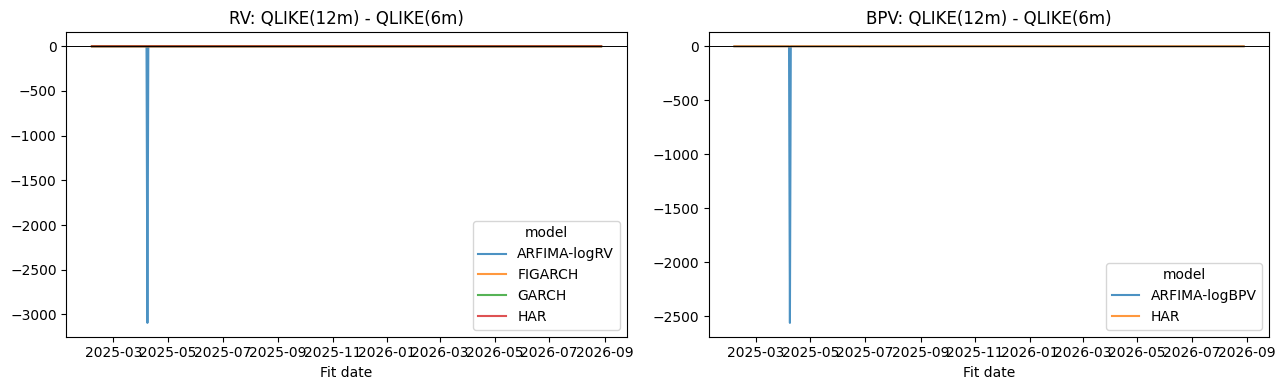

rows
model         target status             
ARFIMA-logBPV bpv    ok          1475520
ARFIMA-logRV  rv     ok          1475520
FIGARCH       rv     fit_failed      615
                     ok          1474905
GARCH         rv     ok          1475520
HAR           bpv    ok          1475520
              rv     ok          1475520

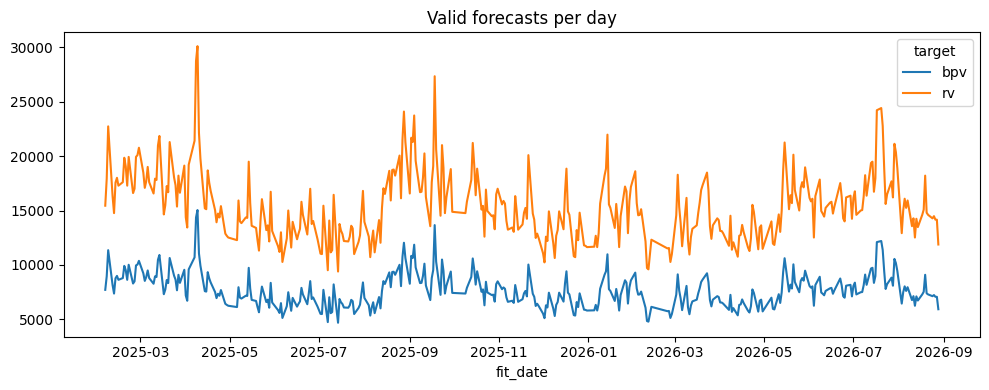

共同成功起点：下一步在同一轴/粒度内配对；15分钟跨所有配置配对。RV/BPV各自取交集。


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,common_origins,qlike,mse
545,validation_2025h1,money,5,0,6,HAR,rv,next_step,97,8876,-12.725934,2.423341e-12
551,validation_2025h1,money,5,0,12,HAR,rv,next_step,97,8876,-12.725558,2.430294e-12
593,validation_2025h1,money,5,360,6,HAR,rv,next_step,97,8876,-12.702461,3.292796e-12
599,validation_2025h1,money,5,360,12,HAR,rv,next_step,97,8876,-12.700328,3.288949e-12
581,validation_2025h1,money,5,120,6,HAR,rv,next_step,97,8876,-12.689932,3.171515e-12
1085,validation_2025h2,money,5,0,6,HAR,rv,next_step,125,11317,-12.688632,1.187600e-12
589,validation_2025h1,money,5,360,6,ARFIMA-logRV,rv,next_step,97,8876,-12.688559,3.282813e-12
587,validation_2025h1,money,5,120,12,HAR,rv,next_step,97,8876,-12.687992,3.217980e-12
1091,validation_2025h2,money,5,0,12,HAR,rv,next_step,125,11317,-12.687772,1.204118e-12
595,validation_2025h1,money,5,360,12,ARFIMA-logRV,rv,next_step,97,8876,-12.686856,3.331815e-12


,fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,days,common_origins,qlike,mse
544,validation_2025h1,money,5,0,6,HAR,bpv,next_step,99,9103,-12.727239,1.839866e-12
550,validation_2025h1,money,5,0,12,HAR,bpv,next_step,99,9103,-12.726952,1.829899e-12
592,validation_2025h1,money,5,360,6,HAR,bpv,next_step,99,9103,-12.706095,2.738578e-12
598,validation_2025h1,money,5,360,12,HAR,bpv,next_step,99,9103,-12.703415,2.714296e-12
580,validation_2025h1,money,5,120,6,HAR,bpv,next_step,99,9103,-12.693191,2.567782e-12
1090,validation_2025h2,money,5,0,12,HAR,bpv,next_step,126,11411,-12.690604,1.112104e-12
586,validation_2025h1,money,5,120,12,HAR,bpv,next_step,99,9103,-12.690228,2.590837e-12
1084,validation_2025h2,money,5,0,6,HAR,bpv,next_step,126,11411,-12.689950,1.100335e-12
568,validation_2025h1,money,5,60,6,HAR,bpv,next_step,99,9103,-12.677256,2.893754e-12
574,validation_2025h1,money,5,60,12,HAR,bpv,next_step,99,9103,-12.674372,2.967586e-12


In [7]:
# 本格实际汇总并展示：各自可用样本 → 6/12 月成对样本 → 全配置共同样本。
if daily_scores_df.empty:
    print("当前选择没有预测结果；检查日参数覆盖日期和运行配置。")
else:
    summary_keys = ["fold_id","clock","equivalent_minutes","seasonality_lookback","fit_window_months","model","target","horizon"]
    # 各配置先使用自己的可用样本，损失按日等权平均；应结合 coverage 查看，不直接当公平排名。
    forecast_summary_df = daily_scores_df.groupby(summary_keys,observed=True).agg(
        days=("fit_date","size"),origins=("origins","sum"),forecasts=("forecasts","sum"),
        qlike=("qlike","mean"),mse=("mse","mean"),
        mean_information_age_minutes=("information_age_minutes","mean"),
        forecast_seconds=("prediction_seconds","sum")).reset_index()
    forecast_summary_df["coverage"] = forecast_summary_df["forecasts"]/forecast_summary_df["origins"]
    for target_name in ["rv","bpv"]:
        print(f"目标 {target_name.upper()}：日均损失；不同目标不得混排")
        display(forecast_summary_df.loc[forecast_summary_df["target"] == target_name].sort_values(
            ["fold_id","clock","equivalent_minutes","qlike"]).head(40))
    # 半年/一年比较使用同模型、同轴/粒度、同季节窗口的共同区间；先日内再跨日平均差值。
    if paired_score_frames:
        paired_daily_df = pd.concat(paired_score_frames,ignore_index=True)
        paired_summary_df = paired_daily_df.groupby(
            ["fold_id","clock","equivalent_minutes","seasonality_lookback","model","target"],observed=True).agg(
                days=("fit_date","size"),common_origins=("common_origins","sum"),
                qlike_12m_minus_6m=("qlike_12m_minus_6m","mean"),
                mse_12m_minus_6m=("mse_12m_minus_6m","mean")).reset_index()
        print("一年减半年：负值表示一年窗口较好，严格使用两窗共同起点。")
        display(paired_summary_df)
        figure,axes = plt.subplots(1,2,figsize=(13,4))
        for axis,target_name in zip(axes,["rv","bpv"]):
            plotted = paired_daily_df.loc[paired_daily_df["target"] == target_name].groupby(
                ["fit_date","model"])["qlike_12m_minus_6m"].mean().unstack("model")
            if len(plotted):
                plotted.plot(ax=axis,alpha=.8)
            axis.axhline(0,color="black",linewidth=.7)
            axis.set_title(f"{target_name.upper()}: QLIKE(12m) - QLIKE(6m)")
            axis.set_xlabel("Fit date")
        figure.tight_layout()
        plt.show()
    display(pd.concat(status_counts,ignore_index=True).groupby(["model","target","status"])["rows"].sum().to_frame())
    figure,axis = plt.subplots(figsize=(10,4))
    daily_scores_df.groupby(["fit_date","target"])["forecasts"].sum().unstack("target").plot(ax=axis)
    axis.set_title("Valid forecasts per day")
    figure.tight_layout()
    plt.show()

    # 公平的跨模型/季节窗口比较优先看这里：同一轴/粒度内所有配置均成功的区间。
    # 空交集意味着这组配置无法在全体共同样本上排名，不自动删除表现差或失败的配置。
    common_nonempty = [frame for frame in common_score_frames if not frame.empty]
    if common_nonempty:
        common_daily_df = pd.concat(common_nonempty,ignore_index=True)
        common_summary_df = common_daily_df.groupby(summary_keys,observed=True).agg(
            days=("fit_date","size"),common_origins=("forecasts","sum"),
            qlike=("qlike","mean"),mse=("mse","mean")).reset_index()
        print("共同成功起点：下一步在同一轴/粒度内配对；15分钟跨所有配置配对。RV/BPV各自取交集。")
        for target_name in ["rv","bpv"]:
            display(common_summary_df.loc[common_summary_df["target"].eq(target_name)].sort_values("qlike").head(30))
    else:
        print("当前配置没有全体共同成功起点；不能把覆盖范围不同的均值解释为公平排名。")


## 6. 实际展示：预测尺度与代理残差

下面展示预测／实际均值比、代理残差偏差与一阶相关、信息年龄。它们是跨配置聚合概览，不能替代上一节的共同样本比较。


In [ ]:
# 本格实际展示尺度与残差诊断；当前聚合会跨 fold、季节窗口、历史窗口平均，仅作概览。
if not daily_scores_df.empty:
    calibration_df = daily_scores_df.groupby(["clock","equivalent_minutes","model","target"]).agg(
        predicted_variance=("mean_prediction","mean"),realized_variance=("mean_actual","mean"),
        relative_error_bias=("relative_error_bias","mean"),relative_error_lag1=("relative_error_lag1","mean"),
        event_progress=("event_progress","mean"),predicted_steps=("predicted_steps","mean"),
        actual_steps=("actual_steps","mean"),information_age_minutes=("information_age_minutes","mean")).reset_index()
    # 比值 >1 表示聚合预测水平偏高，<1 表示偏低；两种均值未强制采用所有配置共同成功样本。
    # prediction_seconds 的统计也只覆盖主循环里计到的部分，不等于整个 Notebook 墙钟耗时。
    calibration_df["prediction_to_actual"] = calibration_df["predicted_variance"]/calibration_df["realized_variance"]
    display(calibration_df)


,clock,equivalent_minutes,model,target,predicted_variance,realized_variance,relative_error_bias,relative_error_lag1,event_progress,predicted_steps,actual_steps,information_age_minutes,prediction_to_actual
0,money,5,ARFIMA-logBPV,bpv,0.000003,0.000002,-0.106065,-0.010138,0.0,1.0,1.0,22.975169,1.621672
1,money,5,ARFIMA-logRV,rv,0.000002,0.000002,-0.043611,-0.034206,0.0,1.0,1.0,22.975169,1.186579
2,money,5,FIGARCH,rv,0.000002,0.000002,0.298336,0.194313,0.0,1.0,1.0,22.975169,0.921490
3,money,5,GARCH,rv,0.000001,0.000002,0.296931,0.183655,0.0,1.0,1.0,22.975169,0.901070
4,money,5,HAR,bpv,0.000002,0.000002,-0.037569,-0.002847,0.0,1.0,1.0,22.975169,1.190669
5,money,5,HAR,rv,0.000002,0.000002,-0.042175,-0.012923,0.0,1.0,1.0,22.975169,1.203990
6,money,10,ARFIMA-logBPV,bpv,0.000004,0.000003,-0.060309,-0.048070,0.0,1.0,1.0,47.283850,1.271980
7,money,10,ARFIMA-logRV,rv,0.000004,0.000003,-0.024625,-0.053489,0.0,1.0,1.0,47.283850,1.180755
8,money,10,FIGARCH,rv,0.000004,0.000003,0.158364,0.200043,0.0,1.0,1.0,47.283850,1.074129
9,money,10,GARCH,rv,0.000004,0.000003,0.158524,0.192807,0.0,1.0,1.0,47.283850,1.071150


## 7. 实际展示：区间收益平方与分钟 RV 的差异

这一步回到输入本身，说明 GARCH 的收益方差和用来评价的分钟贡献 RV 为什么可能存在尺度差异。使用各 fold 全部合格事件，属于观测量诊断。


In [ ]:
# 本格实际比较两种观测量：插值价格的区间收益平方，与按分钟贡献分配得到的区间 RV。
proxy_frames=[]
for fold_id,event_df in observations["events_by_fold"].items():
    # 使用该 fold 全部 eligible 行（包括训练和测试），这是输入口径诊断，不是样本外成绩。
    # 各 fold 单独展示；重叠历史没有拼成一份独立样本。
    eligible_df=event_df.loc[event_df["eligible"]].copy()
    eligible_df["return_squared"]=eligible_df["log_return"]**2
    # 一分钟内拆出的多个采样区间共享分钟信息；这里统计这种比例分配出现的频率。
    eligible_df["subminute"]=(eligible_df["trading_duration_minutes"]<1).astype(int)
    proxy_summary=eligible_df.groupby(["clock","equivalent_minutes"]).agg(
        rv=("rv","mean"),return_squared=("return_squared","mean"),
        subminute_share=("subminute","mean"),mean_step_minutes=("trading_duration_minutes","mean"))
    # 比值接近或偏离 1 只描述两种代理的尺度关系，不能据此判断哪个模型预测更好。
    proxy_summary["return_squared_to_rv"]=proxy_summary["return_squared"]/proxy_summary["rv"]
    proxy_summary["fold_id"]=fold_id
    proxy_frames.append(proxy_summary.reset_index())
print("插值事件收益平方和分钟RV分配并非相同估计量；子分钟尺度尤其明显。状态间断可见information_age_minutes。")
display(pd.concat(proxy_frames,ignore_index=True))


插值事件收益平方和分钟RV分配并非相同估计量；子分钟尺度尤其明显。状态间断可见information_age_minutes。


,clock,equivalent_minutes,rv,return_squared,subminute_share,mean_step_minutes,return_squared_to_rv,fold_id
0,money,5,0.000004,0.000003,0.045292,4.706885,0.786298,final_2026
1,money,10,0.000007,0.000006,0.000894,9.112103,0.866456,final_2026
2,money,15,0.000011,0.000010,0.000000,13.163758,0.921909,final_2026
3,time,5,0.000004,0.000004,0.000000,5.0,0.967314,final_2026
4,time,10,0.000007,0.000007,0.000000,10.0,0.940298,final_2026
5,time,15,0.000011,0.000010,0.000000,15.0,0.928706,final_2026
6,volume,5,0.000004,0.000003,0.030375,4.813876,0.782896,final_2026
7,volume,10,0.000008,0.000006,0.001329,9.345774,0.861137,final_2026
8,volume,15,0.000011,0.000010,0.000000,13.495401,0.899597,final_2026
9,money,5,0.000003,0.000003,0.072668,4.424828,0.760561,validation_2025h1


## 8. 方法依据与解释边界

[Patton（2011）](https://public.econ.duke.edu/~ap172/Patton_vol_proxies_JoE_2011.pdf) 讨论不完美波动代理下的预测比较。QLIKE／MSE 的代理稳健性质依赖条件无偏等假设，不会自动消除分钟插值与事件收益方差之间的口径差异。模型估计和参数还原的具体假设见 [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb)。

本书的代理残差为 `actual / prediction - 1`。偏差和日内一阶相关用于诊断；相邻事件可能共用分钟贡献，且无效区间会造成信息间断，不能据此把记录当作相互独立的显著性样本。公平比较使用第 5 节明确配对的共同区间；第 6、7 节是聚合诊断。
